### Wstęp do Uczenia Maszynowego - praca domowa 3
##### Stanisław Frelik
##### 11.12.2023

### PRZYGOTOWANIE DANYCH
---------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
import sklearn.model_selection as skm
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score

In [20]:
X_train = pd.read_csv("artifical_train_data.csv")
y_train = pd.read_csv("artifical_train_labels.csv")
X_test = pd.read_csv("artifical_test_data.csv")

In [3]:
kfold = skm.KFold(5,
                  random_state=69,
                  shuffle=True)

array([[<AxesSubplot:title={'center':'0'}>,
        <AxesSubplot:title={'center':'1'}>,
        <AxesSubplot:title={'center':'2'}>,
        <AxesSubplot:title={'center':'3'}>,
        <AxesSubplot:title={'center':'4'}>],
       [<AxesSubplot:title={'center':'5'}>,
        <AxesSubplot:title={'center':'6'}>,
        <AxesSubplot:title={'center':'7'}>,
        <AxesSubplot:title={'center':'8'}>,
        <AxesSubplot:title={'center':'9'}>],
       [<AxesSubplot:title={'center':'10'}>,
        <AxesSubplot:title={'center':'11'}>,
        <AxesSubplot:title={'center':'12'}>,
        <AxesSubplot:title={'center':'13'}>,
        <AxesSubplot:title={'center':'14'}>],
       [<AxesSubplot:title={'center':'15'}>,
        <AxesSubplot:title={'center':'16'}>,
        <AxesSubplot:title={'center':'17'}>,
        <AxesSubplot:title={'center':'18'}>,
        <AxesSubplot:title={'center':'19'}>],
       [<AxesSubplot:title={'center':'20'}>,
        <AxesSubplot:title={'center':'21'}>,
        <AxesSub

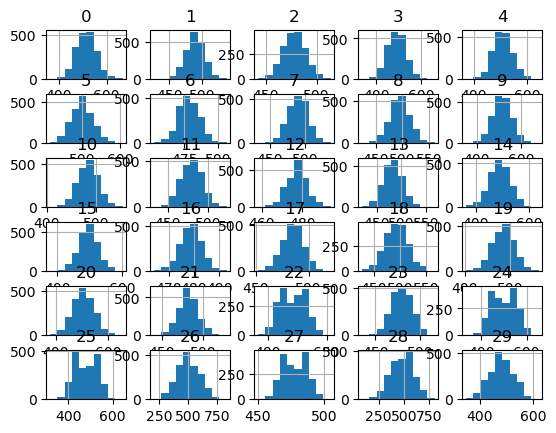

In [32]:
X_train.hist(bins = 10)

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

o istotności zmiennych

In [78]:
pipeline_rf = Pipeline([
    ('scaler', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('rf', RandomForestClassifier(random_state=42069))
])
params_rf = {
    'rf__n_estimators': [50, 100, 200, 300, 400, 500],
    'rf__criterion': ["gini", "entropy", "log_loss"],
    'rf__max_depth': [12, 15, 20, 25, 30],
    'rf__min_samples_split': [2, 3, 4, 5, 7, 10, 15, 20]
    }
grid_pipeline_rf = GridSearchCV(pipeline_rf,
                             cv = kfold,
                             param_grid = params_rf,
                             n_jobs=-1,
                             scoring="balanced_accuracy")

In [79]:
grid_pipeline_rf.fit(X_train, np.ravel(y_train))

GridSearchCV(cv=KFold(n_splits=5, random_state=69, shuffle=True),
             estimator=Pipeline(steps=[('scaler', PowerTransformer()),
                                       ('rf',
                                        RandomForestClassifier(random_state=42069))]),
             n_jobs=-1,
             param_grid={'rf__criterion': ['gini', 'entropy', 'log_loss'],
                         'rf__max_depth': [12, 15, 20, 25, 30],
                         'rf__min_samples_split': [2, 3, 4, 5, 7, 10, 15, 20],
                         'rf__n_estimators': [50, 100, 200, 300, 400, 500]},
             scoring='balanced_accuracy')

In [80]:
grid_pipeline_rf.best_params_

{'rf__criterion': 'entropy',
 'rf__max_depth': 15,
 'rf__min_samples_split': 5,
 'rf__n_estimators': 200}

In [81]:
grid_pipeline_rf.best_score_

0.8086236524539354

In [21]:
pipeline_rf = Pipeline([
    ('scaler', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('rf', RandomForestClassifier(criterion="entropy", max_depth=15, min_samples_split=5, n_estimators=200))
])
pipeline_rf.fit(X_train, np.ravel(y_train))

rf = RandomForestClassifier(criterion="entropy", max_depth=15, min_samples_split=5, n_estimators=200)
rf.fit(X_train, np.ravel(y_train))

RandomForestClassifier(criterion='entropy', max_depth=15, min_samples_split=5,
                       n_estimators=200)

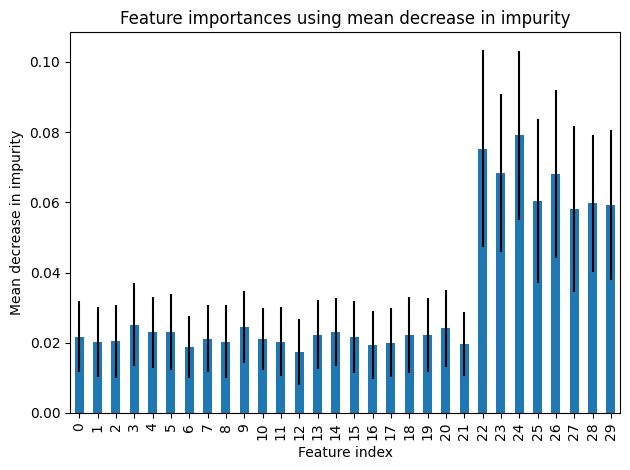

In [22]:
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
feature_names = [f"{i}" for i in range(X_train.shape[1])]
forest_importances = pd.Series(importances, index=feature_names)
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_xlabel("Feature index")
ax.set_title("Feature importances using mean decrease in impurity")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [6]:
pipeline_rf = Pipeline([
    ('scaler', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('rf', RandomForestClassifier(criterion="entropy", max_depth=15, min_samples_split=5, n_estimators=200))
])
pipeline_rf.fit(X_train, np.ravel(y_train))

Pipeline(steps=[('scaler', PowerTransformer()),
                ('rf',
                 RandomForestClassifier(criterion='entropy', max_depth=15,
                                        min_samples_split=5,
                                        n_estimators=200))])

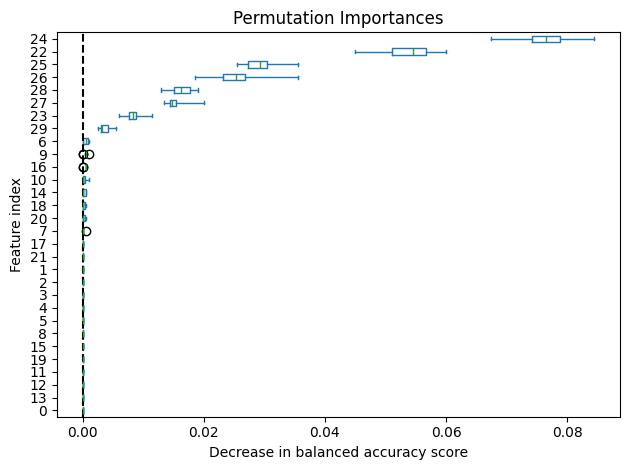

In [7]:
result = permutation_importance(
    pipeline_rf, X_train, y_train, n_repeats=10, random_state=69, n_jobs=-1, scoring='balanced_accuracy'
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_train.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in balanced accuracy score")
ax.set_ylabel("Feature index")
ax.figure.tight_layout()

Czyli 'wywalamy' wszystkie kolumny poza 22-29

In [23]:
X_train_cut = X_train.drop(X_train.iloc[:,np.arange(22)], axis = 1)

In [24]:
X_test_cut = X_test.drop(X_test.iloc[:,np.arange(22)], axis = 1)

In [16]:
X_test

,22,23,24,25,26,27,28,29
0,436,472,541,432,523,486,300,454
1,544,480,456,519,484,484,523,439
2,437,480,517,471,485,477,479,494
3,447,463,425,426,700,472,453,540
4,501,471,537,434,609,470,368,487
...,...,...,...,...,...,...,...,...
595,457,477,530,510,436,482,428,433
596,433,476,513,508,477,468,564,531
597,506,485,520,468,453,494,357,417
598,520,491,520,512,420,469,609,501


array([[<AxesSubplot:title={'center':'22'}>,
        <AxesSubplot:title={'center':'23'}>,
        <AxesSubplot:title={'center':'24'}>],
       [<AxesSubplot:title={'center':'25'}>,
        <AxesSubplot:title={'center':'26'}>,
        <AxesSubplot:title={'center':'27'}>],
       [<AxesSubplot:title={'center':'28'}>,
        <AxesSubplot:title={'center':'29'}>, <AxesSubplot:>]],
      dtype=object)

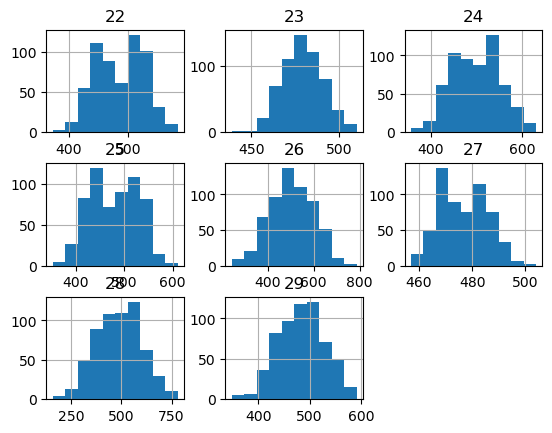

In [17]:
X_test.hist()

In [16]:
y_train

,0
0,-1
1,-1
2,-1
3,1
4,1
...,...
1995,1
1996,-1
1997,-1
1998,1


In [31]:
np.unique(y_train, return_counts=True)

(array([-1,  1], dtype=int64), array([1000, 1000], dtype=int64))

In [247]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   1       2000 non-null   int64
 1   3       2000 non-null   int64
 2   4       2000 non-null   int64
 3   5       2000 non-null   int64
 4   6       2000 non-null   int64
 5   7       2000 non-null   int64
 6   8       2000 non-null   int64
 7   10      2000 non-null   int64
 8   11      2000 non-null   int64
 9   12      2000 non-null   int64
 10  13      2000 non-null   int64
 11  15      2000 non-null   int64
 12  18      2000 non-null   int64
 13  19      2000 non-null   int64
 14  20      2000 non-null   int64
 15  22      2000 non-null   int64
 16  24      2000 non-null   int64
 17  25      2000 non-null   int64
 18  26      2000 non-null   int64
 19  27      2000 non-null   int64
 20  28      2000 non-null   int64
 21  29      2000 non-null   int64
dtypes: int64(22)
memory usage: 343.9 KB


In [24]:
y_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       2000 non-null   int64
dtypes: int64(1)
memory usage: 15.8 KB


In [270]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   1       600 non-null    int64
 1   3       600 non-null    int64
 2   4       600 non-null    int64
 3   5       600 non-null    int64
 4   6       600 non-null    int64
 5   7       600 non-null    int64
 6   8       600 non-null    int64
 7   10      600 non-null    int64
 8   11      600 non-null    int64
 9   12      600 non-null    int64
 10  13      600 non-null    int64
 11  15      600 non-null    int64
 12  18      600 non-null    int64
 13  19      600 non-null    int64
 14  20      600 non-null    int64
 15  22      600 non-null    int64
 16  24      600 non-null    int64
 17  25      600 non-null    int64
 18  26      600 non-null    int64
 19  27      600 non-null    int64
 20  28      600 non-null    int64
 21  29      600 non-null    int64
dtypes: int64(22)
memory usage: 103.2 KB


--------
Dostarjamy modele

In [70]:
pipeline_et = Pipeline([
    ('scaler', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('et', ExtraTreesClassifier(random_state=42069))
])
params_et = {
    'et__n_estimators': [100, 200, 300, 400, 500],
    'et__criterion': ["gini", "entropy", "log_loss"],
    'et__max_depth': [10, 15, 20, 25, 30],
    'et__min_samples_split': [2, 3, 5, 10, 15, 20]
    }

grid_pipeline_et = GridSearchCV(pipeline_et,
                             cv = kfold,
                             param_grid = params_et,
                             n_jobs=-1,
                             scoring="balanced_accuracy")

In [71]:
grid_pipeline_et.fit(X_train_cut, np.ravel(y_train))


GridSearchCV(cv=KFold(n_splits=5, random_state=69, shuffle=True),
             estimator=Pipeline(steps=[('scaler', PowerTransformer()),
                                       ('et',
                                        ExtraTreesClassifier(random_state=42069))]),
             n_jobs=-1,
             param_grid={'et__criterion': ['gini', 'entropy', 'log_loss'],
                         'et__max_depth': [10, 15, 20, 25, 30],
                         'et__min_samples_split': [2, 3, 5, 10, 15, 20],
                         'et__n_estimators': [100, 200, 300, 400, 500]},
             scoring='balanced_accuracy')

In [72]:
grid_pipeline_et.best_params_

{'et__criterion': 'entropy',
 'et__max_depth': 20,
 'et__min_samples_split': 2,
 'et__n_estimators': 500}

In [73]:
grid_pipeline_et.best_score_

0.8875825040866404

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [82]:
pipeline_gradientboosting = Pipeline([
    ('scaler', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('gb', GradientBoostingClassifier(random_state=42069))
])
params_gb = {
    'gb__n_estimators': [100, 200, 300, 400, 500],
    'gb__loss': ["exponential", "log_loss"],
    'gb__min_samples_split': [2, 3, 4, 5, 7, 10, 15, 20, 25],
    'gb__max_depth': [12, 15, 20, 25, 30],
    }

grid_pipeline_gb = GridSearchCV(pipeline_gradientboosting,
                             cv = kfold,
                             param_grid = params_gb,
                             n_jobs=-1,
                             scoring="balanced_accuracy")

In [83]:
grid_pipeline_gb.fit(X_train_cut, np.ravel(y_train))

GridSearchCV(cv=KFold(n_splits=5, random_state=69, shuffle=True),
             estimator=Pipeline(steps=[('scaler', PowerTransformer()),
                                       ('gb',
                                        GradientBoostingClassifier(random_state=42069))]),
             n_jobs=-1,
             param_grid={'gb__loss': ['exponential', 'log_loss'],
                         'gb__max_depth': [12, 15, 20, 25, 30],
                         'gb__min_samples_split': [2, 3, 4, 5, 7, 10, 15, 20,
                                                   25],
                         'gb__n_estimators': [100, 200, 300, 400, 500]},
             scoring='balanced_accuracy')

In [92]:
grid_pipeline_gb.best_params_

{'gb__loss': 'exponential',
 'gb__max_depth': 15,
 'gb__min_samples_split': 15,
 'gb__n_estimators': 400}

In [93]:
grid_pipeline_gb.best_score_

0.8777415850798969

In [86]:
pipeline_bagging = Pipeline([
    ('scaler', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('bagging', BaggingClassifier(estimator = KNeighborsClassifier(), 
                                  n_estimators = 5))
])

params = {
    'bagging__estimator__n_neighbors': [10, 15, 17, 20, 22, 25, 30],
    'bagging__estimator__algorithm': ['ball_tree', 'kd_tree', 'brute'],
    'bagging__n_estimators': [30, 40, 45, 50, 55, 60, 75, 100, 125]
    }

grid_pipeline_bagging = GridSearchCV(pipeline_bagging,
                             cv = kfold,
                             param_grid = params,
                             n_jobs=-1,
                             scoring = 'balanced_accuracy')



In [87]:
grid_pipeline_bagging.fit(X_train_cut, np.ravel(y_train))

GridSearchCV(cv=KFold(n_splits=5, random_state=69, shuffle=True),
             estimator=Pipeline(steps=[('scaler', PowerTransformer()),
                                       ('bagging',
                                        BaggingClassifier(estimator=KNeighborsClassifier(),
                                                          n_estimators=5))]),
             n_jobs=-1,
             param_grid={'bagging__estimator__algorithm': ['ball_tree',
                                                           'kd_tree', 'brute'],
                         'bagging__estimator__n_neighbors': [10, 15, 17, 20, 22,
                                                             25, 30],
                         'bagging__n_estimators': [30, 40, 45, 50, 55, 60, 75,
                                                   100, 125]},
             scoring='balanced_accuracy')

In [90]:
grid_pipeline_bagging.best_params_

{'bagging__estimator__algorithm': 'brute',
 'bagging__estimator__n_neighbors': 10,
 'bagging__n_estimators': 60}

In [91]:
grid_pipeline_bagging.best_score_

0.8890781737448327

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Głosujemy

In [25]:
clf1 = BaggingClassifier(estimator=KNeighborsClassifier(algorithm='brute', n_neighbors=10), n_estimators=60, random_state=42069)
clf2 = GradientBoostingClassifier(loss='exponential', max_depth=15, min_samples_split=15, n_estimators=400, random_state=42069)
clf3 = ExtraTreesClassifier(criterion="entropy", max_depth=20, min_samples_split=2, n_estimators=500, random_state=42069)

pipeline_ensembels = Pipeline([
    ('scaler', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('voting', VotingClassifier(estimators=[('Bagging', clf1),
                                          ('GradientBoosting', clf2),
                                          ('ExtraTrees', clf3)], voting='soft'))
])



In [26]:
pipeline_ensembels.fit(X_train_cut, np.ravel(y_train))

Pipeline(steps=[('scaler', PowerTransformer()),
                ('voting',
                 VotingClassifier(estimators=[('Bagging',
                                               BaggingClassifier(estimator=KNeighborsClassifier(algorithm='brute',
                                                                                                n_neighbors=10),
                                                                 n_estimators=60,
                                                                 random_state=42069)),
                                              ('GradientBoosting',
                                               GradientBoostingClassifier(loss='exponential',
                                                                          max_depth=15,
                                                                          min_samples_split=15,
                                                                          n_estimators=400,
                                                                          random_state=42069)),
                                              ('ExtraTrees',
                                               ExtraTreesClassifier(criterion='entropy',
                                                                    max_depth=20,
                                                                    n_estimators=500,
                                                                    random_state=42069))],
                                  voting='soft'))])

In [27]:
from sklearn.utils import estimator_html_repr

with open("pipeline.html", "w") as f:
    f.write(estimator_html_repr(pipeline_ensembels))

In [11]:
pipeline_ensembels.score(X_train_cut, y_train)

1.0

In [28]:
y_pred = pipeline_ensembels.predict_proba(X_test_cut)

In [29]:
temp = []
for i in range(len(y_pred)):
    temp.append(y_pred[i][1])

In [30]:
temp

[0.062386372424472786,
 0.0209836889913551,
 0.3900417375214249,
 0.9620508921438647,
 0.22765255350292388,
 0.9795861301104591,
 0.15906856048673915,
 0.07216343579145447,
 0.20623257564054906,
 0.9250817368386511,
 0.9581200287891959,
 0.9452203015364677,
 0.09976918210259511,
 0.9187737428445915,
 0.895824304715128,
 0.05258579860937693,
 0.605573249387004,
 0.981752257490688,
 0.5770016473893407,
 0.04368248696073825,
 0.4605791812493439,
 0.0437980075396252,
 0.022912996076460218,
 0.7829002096189045,
 0.9004804553943924,
 0.9772754082166183,
 0.7645325506887994,
 0.26434884048056534,
 0.35997471035086,
 0.02820095090927474,
 0.03860005356022714,
 0.9213071618325946,
 0.9425560651680192,
 0.3416800341525826,
 0.7869797638480202,
 0.07096886475781079,
 0.8372239844636432,
 0.9892606679035251,
 0.7989355612716117,
 0.9630924402153695,
 0.8623842107506511,
 0.9599151768243318,
 0.6549605245096185,
 0.9281838814201322,
 0.1764612702875249,
 0.9871638095238096,
 0.13732602033024055,
 0

In [14]:
scores_cut = cross_val_score(pipeline_ensembels, X_train_cut, y_train, cv = kfold, scoring='balanced_accuracy', n_jobs=-1)
np.mean(scores_cut), np.std(scores_cut)

(0.8846533379719261, 0.019356681623938728)

In [15]:
scores = cross_val_score(pipeline_ensembels, X_train, y_train, cv = kfold, scoring='balanced_accuracy', n_jobs=-1)
np.mean(scores), np.std(scores)

(0.8405021124466936, 0.03340538646667965)

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------